# Exercise 1: Importance Sampling (1D Adaptive Grid)
+	Define a function named **Vegas_Simple(lower, upper, func, n_points, bins, iterations)** to compute a one-dimensional integral using the Importance Sampling method. The regions of importance are defined by the magnitude of the function.

	Hint:

	**Step 1**: Divide the integration range into a specified number of equal-width bins. (Note: For the first iteration, distribute the n_points uniformly across all bins).

	**Step 2**: For each iteration:
	*	Sample random points within each bin and calculate the bin's integral ($I_{bi}$).
	*	Update the number of points for the next iteration $\sim$ the bin's contribution to the total

	$w_{bin_i} = |\dfrac{I_{bi}}{\sum{I_{bj}}} |$.

	Ensure every bin receives at least 2 points to maintain the grid.

	**Step 3**: Return the final estimate in the form $\bar{I} \pm \sigma_{\bar{I}}$, where 
	$\bar{I}$ is the mean of all iterations and 
	$\sigma_{\bar{I}}$ is the standard error calculated as follow:
	+	For every bin $b_i$, the variance is $(\sigma_{\bar{b_i}})^2 = \dfrac{\sigma_{b_i}^2}{n_i}, n_i$ is the number of points in that bin 
	+	The variance of the total integral for a single iteration $j$: $\sigma_{\bar{I_j}}^2 = \sum_{\text{all bins}} \sigma_{\bar{b_i}}^2$
	+	The standard error after N iterations is $\sigma_{\bar{I}} = \frac{1}{N} * \sqrt{\sum\sigma_{\bar{I_j}}^2} $

+	Using your function to compute the following integral:
	$$ I = \int_{0}^{2 \pi} \sin^2(x)dx$$
+	Verify the result by calculating the absolute error: $|\bar{I} - \pi|$
<!-- +	Analyze the convergence: Change the number of points and plot the absolute error and the Standard error (std) as a function of the number of points using log-log scale. Discussion: How do these errors behave as the number of points increases? -->
+	Compare the convergence of the Vegas simple method and the uniform method (using your previous MC_1dim function) by plotting the standard error of both approaches on a log-log scale. Which method has a smaller error? Ensure both methods have the same total number of points (total points = iterations x n_points for Vegas).
+	Modify the Vegas_Simple function so that it returns the results and the total number of random points sampled in each bin across all iterations. Plot the distribution of these points after several iteration steps to observe how the sampling behavior evolves.

VEGAS estimate: 3.1408642016973944
VEGAS error: 0.002952125561914193
True value: 3.141592653589793
Absolute error: 0.0007284518923986738


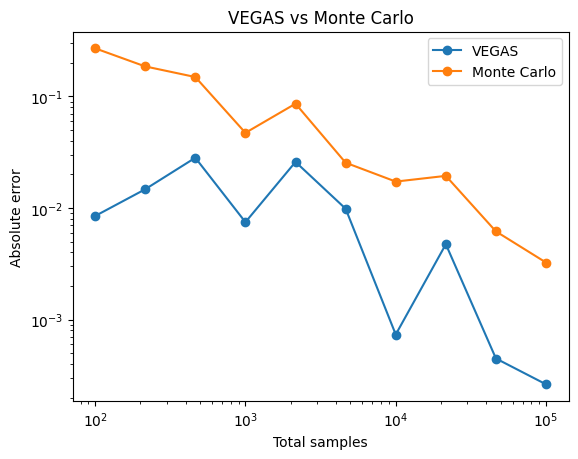

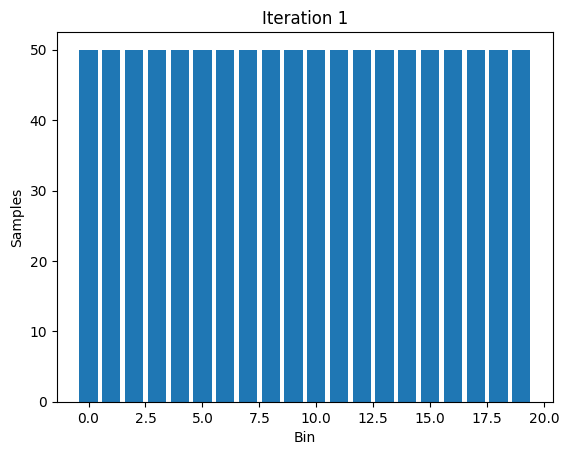

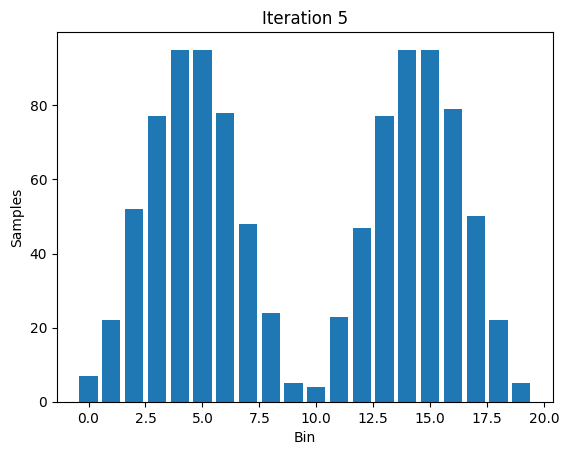

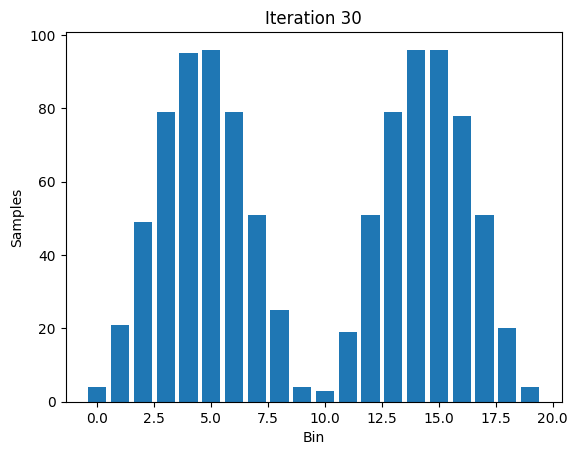

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def Vegas_Simple(lower, upper, func, n_points, bins, iterations):

    # Creating equal-width bins
    edges = np.linspace(lower, upper, bins + 1)

    # Initial uniform allocation of points with distribution of leftovers
    points_per_bin = np.full(bins, n_points // bins, dtype=int)

    rest = n_points - np.sum(points_per_bin)
    for i in range(rest):
        points_per_bin[i] += 1

    estimates = []
    vars_iter = []
    history = []
    total_points = np.zeros(bins, dtype=int)

    for _ in range(iterations):
        bin_integrals = np.zeros(bins)
        bin_vars = np.zeros(bins)

        # Loop over bins
        for i in range(bins):
            left = edges[i]
            right = edges[i + 1]
            width = right - left

            # Ensure at least 2 samples per bin
            n_i = points_per_bin[i]
            if n_i < 2:
                n_i = 2

            # Sample points uniformly inside each bin
            x = np.random.uniform(left, right, n_i)
            y = func(x)

            # Compute mean and variance in the bin
            mean_y = np.mean(y)
            var_y = np.var(y, ddof=1)

            # Estimate contribution of each bin to the integral
            I_i = width * mean_y
            var_i = width**2 * var_y / n_i

            bin_integrals[i] = I_i
            bin_vars[i] = var_i

        # Compute total integral and variance for this iteration
        I = np.sum(bin_integrals)
        var_I = np.sum(bin_vars)

        # Store results from each iteration
        estimates.append(I)
        vars_iter.append(var_I)

        total_points += points_per_bin

        history.append(points_per_bin.copy())

        # Compute weights based on bin contributions
        weights = np.abs(bin_integrals)

        # Normalize weights, avoidding division by zero
        if np.sum(weights) == 0:
            weights = np.ones(bins) / bins
        else:
            weights = weights / np.sum(weights)

        # Allocate new points based on importance sampling
        new_points = np.full(bins, 2, dtype=int)
        free_points = n_points - 2 * bins

        if free_points > 0:
            add_points = np.floor(weights * free_points).astype(int)
            new_points += add_points

            # Distribute points lost due to rounding
            missing = free_points - np.sum(add_points)
            if missing > 0:
                order = np.argsort(-weights)
                for j in range(missing):
                    new_points[order[j]] += 1

        # Update sampling for next iteration
        points_per_bin = new_points

    # Final estimate as average over iterations
    I_final = np.mean(estimates)

    # Estimate final error
    error = (1 / iterations) * np.sqrt(np.sum(vars_iter))

    return I_final, error, total_points, history

#Monte Carlo for 1d 
def mc_1d(f, a, b, N):
    x = np.random.uniform(a, b, N)
    return (b - a) * np.mean(f(x))

# function sin^2(x)
def func(x):
    return np.sin(x)**2

I_vegas, err_vegas, pts, history = Vegas_Simple(0, 2 * np.pi, func, 1000, 20, 30)

print("VEGAS estimate:", I_vegas)
print("VEGAS error:", err_vegas)
print("True value:", np.pi)
print("Absolute error:", abs(I_vegas - np.pi))

Ns = np.logspace(2, 5, 10).astype(int)

vegas_errors = []
mc_errors = []

for N in Ns:
    # total number of VEGAS samples = (N//10) * 10 ~= N
    I_v, _, _ , _ = Vegas_Simple(0, 2 * np.pi, func, N // 10, 20, 10)
    I_mc = mc_1d(func, 0, 2 * np.pi, N)

    vegas_errors.append(abs(I_v - np.pi))
    mc_errors.append(abs(I_mc - np.pi))

plt.figure()
plt.loglog(Ns, vegas_errors, marker="o", label="VEGAS")
plt.loglog(Ns, mc_errors, marker="o", label="Monte Carlo")
plt.xlabel("Total samples")
plt.ylabel("Absolute error")
plt.title("VEGAS vs Monte Carlo")
plt.legend()
plt.show()

I_vegas, err_vegas, total_points, history = Vegas_Simple(0, 2 * np.pi, func, 1000, 20, 30)

for k in [0, 4, len(history) - 1]:
    plt.figure()
    plt.bar(range(len(history[k])), history[k])
    plt.xlabel("Bin")
    plt.ylabel("Samples")
    plt.title(f"Iteration {k + 1}")
    plt.show()

### Exercise 1 Discussion

The results show that both methods improve as the number of sampled points increases, but the VEGAS method generally achieves a lower error compared to standard Monte Carlo for the same number of samples.

This is expected, since VEGAS uses adaptive importance sampling. Instead of sampling uniformly across the whole interval, it allocates more points to regions where the function contributes more to the integral. As a result, the variance of the estimate is reduced.

For the function $\sin^2(x)$, the improvement is visible but not very large. This is because the function is relatively smooth and does not contain sharp peaks. In more irregular cases, the advantage of importance sampling would be more significant.

The convergence behavior of both methods still follows the typical Monte Carlo rate of approximately $\frac{1}{\sqrt{N}}$. However, VEGAS achieves a smaller error for the same number of samples.

The distribution of sampled points across bins confirms that the algorithm adapts over iterations. Bins with larger contributions receive more samples, while less important regions are sampled less frequently.

#### Final conclusion

The VEGAS method improves the efficiency of Monte Carlo integration by reducing variance through adaptive sampling. While the convergence rate remains the same, the overall accuracy is better for the same number of samples.

# Exercise 2: Generate different distributions
Use the uniform distribution to generate an exponential distribution $p(x) = e^{-x}$ and a Gaussian distribution (using the formular in the lecture). Plot the histogram to check the results.

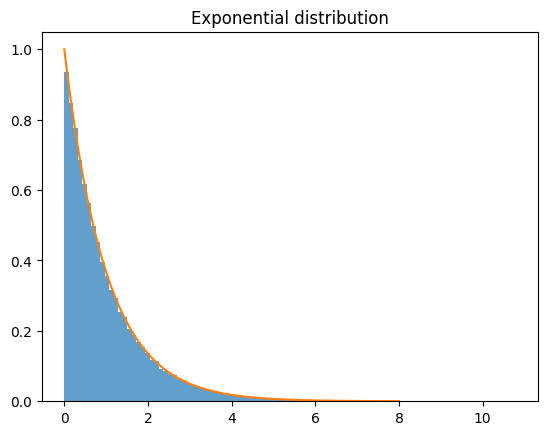

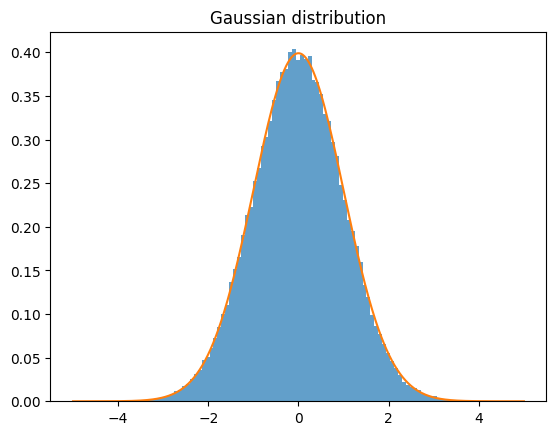

In [31]:
def sample_exponential(N):
    u = np.random.uniform(0, 1, N)
    x = -np.log(u)
    return x

# Gaussian distribution using Box-Muller
def sample_gaussian(N):
    u1 = np.random.uniform(0, 1, N)
    u2 = np.random.uniform(0, 1, N)

    z1 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
    z2 = np.sqrt(-2 * np.log(u1)) * np.sin(2 * np.pi * u2)

    return z1

N = 100000

# Exponential
exp_samples = sample_exponential(N)

plt.figure()
plt.hist(exp_samples, bins=100, density=True, alpha=0.7)
x = np.linspace(0, 8, 500)
plt.plot(x, np.exp(-x))
plt.title("Exponential distribution")
plt.show()

# Gaussian
gauss_samples = sample_gaussian(N)

plt.figure()
plt.hist(gauss_samples, bins=100, density=True, alpha=0.7)
x = np.linspace(-5, 5, 500)
plt.plot(x, (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2))
plt.title("Gaussian distribution")
plt.show()

### Exercise 2: Discussion

The exponential and Gaussian distributions were successfully generated from a uniform distribution using transformation methods.

For the exponential distribution, the inverse transform method was applied. The resulting histogram matches the theoretical probability density function $p(x) = e^{-x}$, which confirms that the transformation was implemented correctly.

For the Gaussian distribution, the Box-Muller transform was used. The generated samples form a symmetric bell-shaped curve centered around zero, which is consistent with the standard normal distribution.

Some small fluctuations in the histograms are visible, especially in the tails. This is expected due to the randomness of sampling and the finite number of points. Increasing the number of samples would make the histograms smoother and closer to the theoretical curves.

Overall, both methods demonstrate how non-uniform distributions can be obtained from a uniform distribution using appropriate transformations.

#### Final conclusion

The results confirm that transformation techniques such as inverse transform sampling and the Box-Muller method allow efficient generation of non-uniform distributions from uniform random numbers.